# FX Pairs: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error
in it is silent where it is made and reaches every metric and every backtest after it.
This notebook fixes which price is bought and which is sold, proves each labelled row has
a complete forward window inside one pair, measures how much independent information those
rows carry, measures what a plain trailing return already predicts, and writes the label
files the evaluation and modelling notebooks read.

## Learning objectives

- Aggregate a continuously quoted bar series into the daily periods a trading decision is
  actually taken in, before any forward return is measured off it
- Write assertions that fail when a forward return is incomplete, is computed across two
  different instruments, or spans a stretch where an instrument stopped quoting
- Restrict a diagnostic to the history whose outcomes are already known, using the date a
  forward return finishes on rather than the date it starts from
- Measure how much of its forward window one row shares with the next, and convert a row
  count into the number of independent observations those rows are worth
- Measure how well a plain trailing return already orders tomorrow's returns, so that later
  feature work has a number to beat, under a standard error that allows for the dependence
  between overlapping rows

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads four-hour spot bars through `load_fx_pairs()`, whose
coverage [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the universe, the label set, the horizons and the date
the holdout opens. Writes `labels/fwd_ret_1d.parquet`, `labels/fwd_ret_5d.parquet` and
`labels/fwd_ret_21d.parquet`. [`05_evaluation`](05_evaluation.ipynb) reads all three and
takes which of them is primary from `setup.yaml`; the modelling notebooks from
[`06_linear`](06_linear.ipynb) onward train on the primary one.

In [1]:
"""FX Pairs: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_fx_pairs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "fx_pairs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the
history to a later start; `MAX_SYMBOLS` keeps only the first pairs in alphabetical order.
Either one shortens a run at the cost of a thinner panel: the rank correlation in Section G
and the cross-sectional dispersion in Section E both need a wide cross-section on each
session to mean anything.

In [2]:
MAX_SYMBOLS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

A **session** is one trading day as this market counts them. Spot currencies quote
continuously from Sunday evening to Friday evening, so where an exchange would hand you a
closing bell, here a calendar has to decide where one day ends and the next begins;
Section B is where that decision is made and applied. Every horizon below is a number of
sessions, never a number of calendar days.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
all three are declared in trading sessions.

Each value below is printed as a statement of what it decides rather than as a name and a
number, because a reader deciding whether any of this transfers to their own data needs to
know what would change if it were different.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
LONGEST_LABEL = max(HORIZONS, key=HORIZONS.get)
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
HOLDOUT_END = date.fromisoformat(setup["evaluation"]["holdout_end"])
CALENDAR = setup["decision"]["session_calendar"]
RANKED_RETURNS = [name for name in setup["features"]["ranked"] if name.startswith("ret_")]
LOOKBACK = max(int(name.removeprefix("ret_").removesuffix("d")) for name in RANKED_RETURNS)

print(f"{PRIMARY_LABEL} is the label every model is trained on: the spot return over the")
print(f"  next {PRIMARY_HORIZON} session{'s' * (PRIMARY_HORIZON != 1)}, matching the")
print(f"  {setup['decision']['cadence']} cadence at which positions may be changed.")
for name in LABEL_NAMES[1:]:
    print(f"{name} is written alongside it, over {HORIZONS[name]} sessions, so a later")
    print("  notebook can ask how far out the same ordering still holds.")
print(f"The {CALENDAR} calendar decides which four-hour bar belongs to which session, because")
print(f"  spot currencies quote around the clock. The holdout runs {HOLDOUT_START} to")
print(f"  {HOLDOUT_END}; no diagnostic below reads a return that finishes inside it.")
print(f"The signal Section G measures is the trailing {LOOKBACK}-session return, the longest")
print(f"  of the trailing returns setup.yaml ranks across pairs ({', '.join(RANKED_RETURNS)}).")

fwd_ret_1d is the label every model is trained on: the spot return over the
  next 1 session, matching the
  daily_ny_close cadence at which positions may be changed.
fwd_ret_5d is written alongside it, over 5 sessions, so a later
  notebook can ask how far out the same ordering still holds.
fwd_ret_21d is written alongside it, over 21 sessions, so a later
  notebook can ask how far out the same ordering still holds.
The CME_FX calendar decides which four-hour bar belongs to which session, because
  spot currencies quote around the clock. The holdout runs 2024-01-01 to
  2025-12-31; no diagnostic below reads a return that finishes inside it.
The signal Section G measures is the trailing 126-session return, the longest
  of the trailing returns setup.yaml ranks across pairs (ret_21d, ret_63d, ret_126d).


## A. The learning task

`setup.yaml::mapping` describes a strategy that sorts the twenty currency pairs once a day,
buys the ones at the top of the ordering and sells the ones at the bottom. That shape makes
the question a relative one: not whether a pair will rise, but whether it will end up above
or below the other nineteen. So the outcome to predict is each pair's own forward spot
return, and a model is judged on the ordering it puts those returns in.

Which way the ordering should run is not settled at this stage. `setup.yaml::mapping`
names ranking by momentum, and `setup.yaml::features` then declares two families that read
the same trailing prices and disagree about the sign of the effect: momentum, on the claim
that a pair that has moved keeps moving, and mean reversion, on the claim that a pair
stretched against its own recent range comes back. The label is the same forward return
under either reading, `03_financial_features` builds both families, and `05_evaluation` is
where the sign is measured per horizon. That is why Section G below reports the sign it
finds rather than checking one decided in advance.

The decision cadence comes from `setup.yaml::decision`: the New York 5pm close is observed
and the resulting position is entered at the next bar's open, which fixes the primary
horizon at one session. The two variants ask whether the same relationship pays over a week
and over a month - questions about how fast the effect fades and about how often the book
has to turn over, rather than second hypotheses. Section G therefore measures the baseline
against the primary label alone, and `05_evaluation` compares the three.

## B. Preparation before the label

Spot FX has no exchange close, so a daily bar is a convention rather than an observation.
The provider delivers four-hour bars stamped in UTC; the decision cadence is defined at the
New York 5pm rollover, and for eight hours out of every twenty-four the two clocks put a
bar on different calendar days. `TradingCalendar`, on the venue calendar
`setup.yaml::decision.session_calendar` declares, assigns each four-hour bar to the session
it actually traded in, and the daily close is the last bar of that session rather than the
last bar before midnight UTC. Aggregating on the UTC date
instead puts a Sunday-evening bar and the Monday session in the same row.

The aggregation sorts within each session group before taking its last bar, because a
Polars `group_by` does not contractually preserve input order, and a daily close taken
from an arbitrary bar of the session is wrong without ever raising.

No eligibility filter runs before the shift, and that ordering matters: once rows are
dropped from inside a series, a shift counts survivors, the horizon stops being measured in
sessions, and the window silently spans whatever was removed. The universe is the fixed
twenty-pair list `setup.yaml` declares, which carries the selection bias
`01_feasibility_analysis` documents.

The pairs are listed below rather than counted, split the way this market splits them: a
pair with the US dollar on one side is quoted directly by a bank, and a pair without one -
a **cross** - is quoted by combining two dollar pairs, which is why it costs more to trade.
The split is worth seeing before any label is built: a cross moves with two dollar prices
rather than one, so how many of them a universe holds is part of what its returns look like.

In [4]:
def to_daily_sessions(bars: pl.DataFrame) -> pl.DataFrame:
    """Aggregate four-hour bars to one row per pair and trading session."""
    sessions = TradingCalendar(CALENDAR).get_sessions(pd.DatetimeIndex(bars["timestamp"]))
    return (
        bars.rename({"timestamp": "bar_ts"})
        .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
        .drop_nulls("timestamp")
        .group_by(["symbol", "timestamp"])
        .agg(pl.col("close").sort_by("bar_ts").last())
        .sort(["symbol", "timestamp"])
    )


bars = load_fx_pairs(frequency="4h", start_date=START_DATE, end_date=str(HOLDOUT_END))
prices = to_daily_sessions(bars.select(["symbol", "timestamp", "close"]))
if MAX_SYMBOLS is not None:
    keep = sorted(prices["symbol"].unique().to_list())[:MAX_SYMBOLS]
    prices = prices.filter(pl.col("symbol").is_in(keep))

assert prices.filter(pl.col("timestamp").dt.weekday() > 5).height == 0, "weekend session"

# Digest of the data the labels are built from, recorded as every label's `inputs`: a
# re-run against a refreshed download is otherwise indistinguishable from this one.
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

universe = sorted(prices["symbol"].unique().to_list())
against_usd, crosses = [s for s in universe if "USD" in s], [s for s in universe if "USD" not in s]
print(f"{len(universe)} pairs, {prices.height:,} pair-sessions")
print(f"Sessions {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"{len(against_usd)} quote against the US dollar: {', '.join(against_usd)}")
print(f"{len(crosses)} are crosses, combined from two dollar pairs and so quoted at a wider")
print(f"  spread: {', '.join(crosses)}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

20 pairs, 77,480 pair-sessions
Sessions 2011-01-03 to 2025-12-31
7 quote against the US dollar: AUD_USD, EUR_USD, GBP_USD, NZD_USD, USD_CAD, USD_CHF, USD_JPY
13 are crosses, combined from two dollar pairs and so quoted at a wider
  spread: AUD_JPY, AUD_NZD, CAD_JPY, CHF_JPY, EUR_AUD, EUR_CAD, EUR_CHF, EUR_GBP, EUR_JPY, GBP_AUD, GBP_CHF, GBP_JPY, NZD_JPY
market_data digest: ee846141912988f9


## C. Label construction

One execution convention, written once and applied at all three horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is pair $i$'s New York 5pm close and $t+h$ counts $h$ sessions for that pair:
Chapter 7.2's close-to-close convention. The backtest fills somewhere else -
`setup.yaml::decision.execution_delay` puts the trade at the next bar's open, a few hours
after the price this return starts from. A model trained on this label is therefore
predicting slightly more than it will be paid for, and the difference is a cost that
nothing in this notebook measures.

Two bookkeeping columns are numbered here, on the complete session series, because both
mean something only before a row is dropped: `from_end` counts back from each pair's last
session for Section D's boundary profile, and `session` numbers its sessions forward so
Section F's overlap statistics keep counting sessions once the null tail and the holdout
are filtered out. Neither reaches a label parquet, which selects three columns.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` trading sessions, per pair."""
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end"),
    pl.int_range(pl.len()).over("symbol").alias("session"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)
labels_df = labels_df.with_columns(
    pl.col("timestamp").shift(-PRIMARY_HORIZON).over("symbol").alias("_label_end")
)

print(f"Constructed {', '.join(LABEL_NAMES)}")

Constructed fwd_ret_1d, fwd_ret_5d, fwd_ret_21d


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The first assertion is the one that makes "$h$ sessions" mean what it says. The shift moves
by rows, so it measures sessions only while a pair has a row for every session the panel
has; a pair that stopped quoting for a fortnight would have its window close a fortnight
late, at the same row offset, with nothing raising. Rather than bound how far a window may
stretch in calendar days and hope the bound is tight enough, the check asserts the property
that would make such a stretch impossible: every pair quotes on every session in the sample.
That is a fact about this data and not about this code, which is why it is executed here
rather than stated - a universe with delistings or trading halts would fail it, and the
horizons would then have to be expressed as durations with a tolerance instead.

The calendar spans printed beneath are then descriptive rather than protective. They say
how much wall-clock time each horizon covers, which is not a fixed multiple: a five-session
return spans a week or more depending on where weekends and holidays fall inside it, and
that is the number to quote when comparing this horizon against one in another market.

In [6]:
sessions_per_pair = labels_df.group_by("symbol").agg(pl.col("timestamp").n_unique().alias("n"))
n_sessions = labels_df["timestamp"].n_unique()

# 1. Every pair quotes on every session, so a shift of h rows is a shift of h sessions.
assert sessions_per_pair["n"].min() == n_sessions, "a pair is missing a session"

for label_name, horizon in HORIZONS.items():
    checked = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = checked.filter(pl.col("from_end") < horizon)
    labelled = checked.drop_nulls(label_name)

    # 2. An incomplete forward window is null, never a value.
    assert tail[label_name].null_count() == tail.height, label_name

    # 3. No label crosses a pair boundary: the labelled count equals the session count less
    #    `horizon` rows per pair, which holds only if every window closed in its own pair.
    expected = prices.height - horizon * prices["symbol"].n_unique()
    assert labelled.height == expected, label_name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    print(
        f"{label_name}: {labelled.height:,} labelled, {tail.height:,} tail rows null, "
        f"windows span up to {labelled['_span'].max()} calendar days"
    )

fwd_ret_1d: 77,460 labelled, 20 tail rows null, windows span up to 4 calendar days
fwd_ret_5d: 77,380 labelled, 100 tail rows null, windows span up to 11 calendar days
fwd_ret_21d: 77,060 labelled, 420 tail rows null, windows span up to 33 calendar days


Position zero below is each pair's last session. The non-null rate has to fall to zero over
exactly the last `horizon` positions and sit flat beyond them. A scalar count of valid rows
shows neither failure this catches: a tail fabricated instead of nulled, or a short label
masked by a longer one's null set. The figure reads which rows are null and never reads a
return, so it is drawn over the whole sample: it describes the file, not the market.

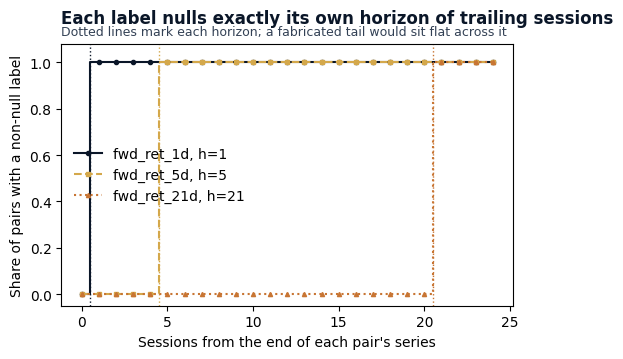

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)
palette = (COLORS["blue"], COLORS["amber"], COLORS["copper"])
markers = ("o-", "s--", "^:")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(LABEL_NAMES, palette, markers, strict=True):
    tag = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", ms=3, c=colour, label=tag)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each pair's series")
ax.set_ylabel("Share of pairs with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label nulls exactly its own horizon of trailing sessions",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each pair's series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing in every regime? Everything from
here through Section G is computed on the history before the holdout opens, and the date
that decides whether a row is inside that history is the date its forward window
**finishes**, not the date it starts from. The two differ by the horizon, and the
difference is the whole point: a row observed a week before the holdout, carrying a
twenty-one-session return, is measuring price movements that happen inside the holdout. A
filter on the observation date would keep it. The label files themselves keep every row,
because this rule governs what the notebook is allowed to look at, not what it writes. The
history the rule leaves available is what the rest of this notebook calls the **development
window**, and it is what every figure and statistic below is drawn on.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_1d: 67,080 development rows through 2023-12-28
fwd_ret_5d: 67,000 development rows through 2023-12-21
fwd_ret_21d: 66,680 development rows through 2023-11-29


All three labels go on one axis with identical bins and a logarithmic count axis. The claim
the figure has to support is about shape rather than width, which three dispersion scalars
would carry: each longer horizon spreads the same centred body wider. The axis is narrower
than every label's range, so rows outside it are counted below rather than drawn, and the
figure is therefore evidence about the body and not about the tails. The skew printed
beneath it is the quantity that does read the tails, and for the one-session label the two
disagree: a handful of sessions of sharp depreciation sit outside the drawn range and pull
it well negative. That asymmetry is a property of a daily FX label, and a plot of its
central mass cannot show it.

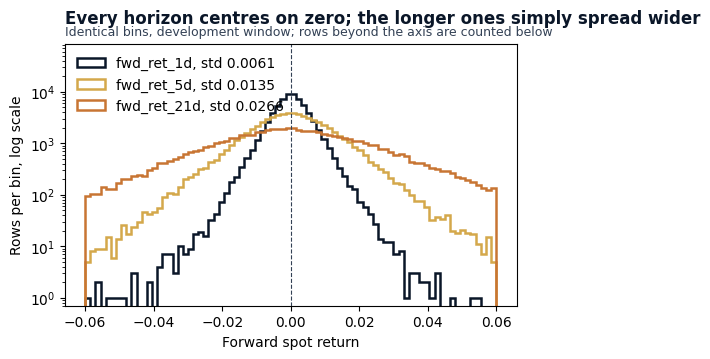

fwd_ret_1d: std 0.00610, skew -0.762, share positive 0.503, 9 left and 5 right of the axis
fwd_ret_5d: std 0.01348, skew -0.173, share positive 0.503, 87 left and 82 right of the axis
fwd_ret_21d: std 0.02664, skew +0.021, share positive 0.504, 1,047 left and 1,375 right of the axis
width ratio 4.37 against 4.58 under square-root-of-horizon scaling


In [9]:
bins = np.linspace(-0.06, 0.06, 81)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, palette, strict=True):
    series = dev[name][name]
    tag = f"{name}, std {series.std():.4f}"
    ax.hist(series.to_numpy(), bins=bins, histtype="step", lw=1.8, color=colour, label=tag)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward spot return")
ax.set_ylabel("Rows per bin, log scale")
ax.set_ylim(0.7, ax.get_ylim()[1] * 6)  # headroom so the legend clears the tallest bin
add_message_title(
    ax,
    "Every horizon centres on zero; the longer ones simply spread wider",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Histograms of the three labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
for name in LABEL_NAMES:
    frame, column = dev[name], pl.col(name)
    out = frame.filter(column < bins[0]).height, frame.filter(column > bins[-1]).height
    print(
        f"{name}: std {std[name]:.5f}, skew {frame[name].skew():+.3f}, share positive "
        f"{(frame[name] > 0).mean():.3f}, {out[0]:,} left and {out[1]:,} right of the axis"
    )
ratio = std[LONGEST_LABEL] / std[PRIMARY_LABEL]
root_h = math.sqrt(HORIZONS[LONGEST_LABEL] / PRIMARY_HORIZON)
print(f"width ratio {ratio:.2f} against {root_h:.2f} under square-root-of-horizon scaling")

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where the spread narrows, the same rank correlation converts into less return.
The spread is taken across pairs on each session first and only then averaged over the
year. Pooling every pair-session in a year into one standard deviation instead measures
something else: it adds the movement of the panel's own mean from session to session to the
spread across pairs on a session, and a ranking model is scored on the second alone.

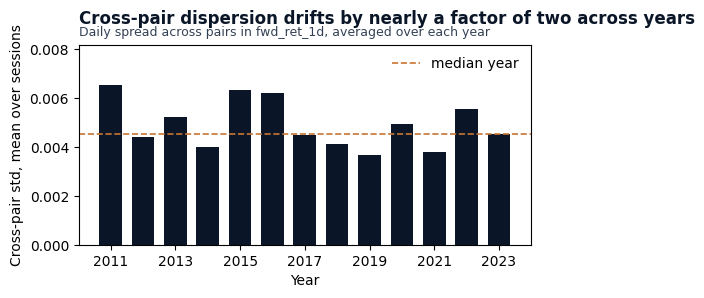

dispersion peaks at 0.65% in 2011 against 0.36% in 2019, a ratio of 1.79; median year 0.45%


In [10]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-pair std, mean over sessions")
ax.set_ylim(0, annual["dispersion"].max() * 1.25)  # headroom so the legend clears the bars
add_message_title(
    ax,
    "Cross-pair dispersion drifts by nearly a factor of two across years",
    subtitle=f"Daily spread across pairs in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-pair dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.2%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.2%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.2%}"
)

On the development window the one-session label has a standard deviation of 0.00610 and
the monthly label 0.02664, a ratio of 4.37 against the 4.58 that square-root-of-horizon
scaling implies. All three are close to balanced around zero - the share of positive rows
runs 0.503 to 0.504 - so the task is not one of predicting a drift but of ranking small
deviations from it. The tails are not balanced at the daily horizon: skew runs -0.762 at
one session against -0.173 at five and +0.021 at twenty-one, so the one-session label
carries a left tail the longer two average away. The spread the ranking happens inside is
not constant either: cross-pair dispersion peaks at 0.65% in 2011 against 0.36% in 2019, a
ratio of 1.79.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and how many independent rows the overlapping
ones amount to. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting
per pair, because how many windows are open at once is a property of one pair's own series.

The one-session label is the case that checks the measurement rather than the data.
Consecutive one-session forward returns are built from disjoint return intervals, so no row
shares any part of its window with a neighbour, every uniqueness weight must be one, and
the effective count has to come back equal to the row count. A weighting that counted the
anchor session as consumed would halve it instead, and would read as a refinement.

Rows that share no part of their windows can still be dependent, and the figure is what
shows it. The one-session label overlaps nothing, yet its autocorrelation is small rather
than zero at every lag drawn. The uniqueness weighting only removes the double-counting
that overlapping windows cause; it says nothing about whether returns are correlated in
time, which is why the standard error in Section G still has to be corrected separately.

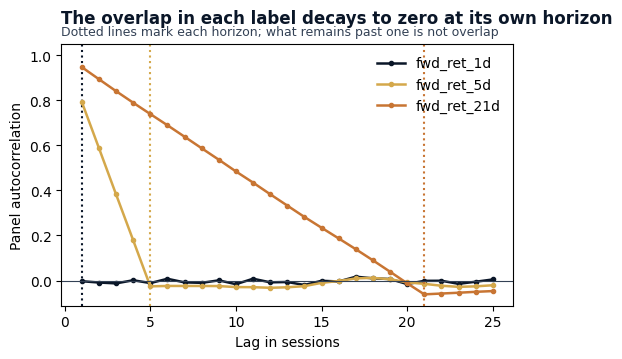

fwd_ret_1d: N=67,080, N_eff=67,080, ratio 1.0000 against 1.0000 for windows overlapping this fully; autocorrelation -0.003 at lag one


fwd_ret_5d: N=67,000, N_eff=13,416, ratio 0.2002 against 0.2000 for windows overlapping this fully; autocorrelation +0.792 at lag one, -0.026 at lag 5


fwd_ret_21d: N=66,680, N_eff=3,194, ratio 0.0479 against 0.0476 for windows overlapping this fully; autocorrelation +0.947 at lag one, -0.061 at lag 21


In [11]:
max_lag = HORIZONS[LONGEST_LABEL] + 4
acf = {n: panel_autocorrelation(dev[n], n, max_lag=max_lag, bar_col="session") for n in LABEL_NAMES}
lags = np.arange(1, max_lag + 1)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, palette, strict=True):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in sessions")
ax.set_ylabel("Panel autocorrelation")
ax.set_ylim(top=1.05)  # headroom so the lag-one point is not drawn on the top spine
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of the three labels against lag in sessions.")

# A horizon-h label consumes the h returns realised over its window, and its neighbour one
# session later shares h-1 of them, so average uniqueness converges to 1/h.
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[label_name], horizon=horizon, bar_col="session")
    at_h = "" if horizon == 1 else f", {acf[label_name][horizon - 1]:+.3f} at lag {horizon}"
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:+.3f} at lag one{at_h}"
    )

The one-session label's 67,080 development rows carry 67,080 effective observations, the
answer that confirms the weighting rather than the data: consecutive windows are disjoint,
so every uniqueness weight is one. The weekly label's 67,000 rows carry 13,416, a ratio of
0.2002 against 0.2000, and the monthly label's 66,680 rows carry 3,194, a ratio of 0.0479
against 0.0476. Autocorrelation is -0.003 at lag one for the one-session label, +0.792 for
the weekly and +0.947 for the monthly, and each falls to zero at its own horizon. The purge
gap a fold needs is set by the forward window itself, not by these counts.

## G. Baseline floor

Before any feature is built, one signal is measured against the primary label over the
development window, so that the feature work in the next notebook has a number to be
compared against. The signal is the plain trailing return over the longest window
`setup.yaml` ranks across pairs, which `03_financial_features` rebuilds as `ret_126d`. It
is deliberately the simplest thing that could carry the effect: an engineered feature that
does no better than a raw return has added nothing, and this is the number that says so.

Section A left the sign open, and this is where it becomes visible. Momentum predicts that
a pair that has risen over the window keeps rising, which is a **positive** information
coefficient; mean reversion predicts a **negative** one. The same number therefore supports
opposite readings depending on which way it points, so the sign is read off the measurement
rather than assumed before it.

The coefficient is the cross-sectional rank correlation on each session, averaged over
sessions, which is the quantity a ranking model is scored on; pooling every pair-session
instead mixes a cross-sectional claim with a time-series one. The library call returns its
series ordered by time, which the standard error depends on. The minimum cross-section is
half the median rather than a bare count, so it means the same thing on a universe of
another size. The primary label does not overlap, but its series of daily coefficients is
still serially dependent, because the trailing return that produces it moves slowly, so the
standard error is HAC-adjusted and the Newey-West rule sets the bandwidth. The period count
reported is the one the statistic used: a session whose cross-section falls below the
minimum yields no coefficient and is not averaged over.

In [12]:
SIGNAL = f"ret_{LOOKBACK}d"

baseline = (
    labels_df.with_columns(
        (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias(SIGNAL)
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls([PRIMARY_LABEL, SIGNAL])
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col=SIGNAL,
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: {SIGNAL} against {PRIMARY_LABEL}, {baseline.height:,} rows, "
    f"minimum cross-section {min_obs} pairs"
)
print(f"  sessions scored {stats['n_periods']:,}, mean IC {stats['mean_ic']:+.4f}")
print(
    f"  HAC t {stats['t_stat']:+.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:+.2f}, p {stats['p_value']:.3g}"
)

Baseline: ret_126d against fwd_ret_1d, 64,560 rows, minimum cross-section 10 pairs
  sessions scored 3,228, mean IC +0.0035
  HAC t +0.46 on 8 Bartlett lags, naive t +0.43, p 0.649


The trailing 126-session return earns a mean information coefficient of +0.0035 against the
one-session label, over 3,228 scored sessions on a cross-section of at least 10 pairs. The
sign is the one momentum predicts and the opposite of the one mean reversion predicts, and
it cannot be read as either: neither the naive t-statistic of +0.43 nor the HAC statistic
of +0.46 on 8 Bartlett lags separates the coefficient from zero, at a p-value of 0.649. The
raw trailing return leaves the direction undetermined at this horizon, so the number a
feature has to beat is zero and both families in the register are still open.

## H. Artifacts and the audit record

Each label goes to its own parquet file. Beside each one, `write_artifact` leaves a small
JSON file with the same name and a `.digest.json` suffix. Its job is to make a data file
self-describing, so that someone holding a result months later can tell whether it came
from these exact values or from a re-run against a refreshed download - which two parquets
of identical shape cannot otherwise be told apart on.

It holds a hash computed over the values in the file, so any changed return changes it
while re-ordering the rows does not; the number of rows; the columns that identify a row,
here the timestamp and the pair; the notebook that wrote it; and the hash of the price
series the returns were computed from, which is the field that ties a label to its data
vintage.

The folds that train models are derived from the timeline of the label parquet written
here, spaced by the walk-forward window `config/setup.yaml` declares, so which rows land in
a label sets where its fold boundaries fall.

In [13]:
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_1d.parquet: 77,460 rows, digest 38a71b059d90d7f6
fwd_ret_5d.parquet: 77,380 rows, digest f626c04c286f525a
fwd_ret_21d.parquet: 77,060 rows, digest 8ea4f735324607a6


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand.

In [14]:
readers = dict.fromkeys(LABEL_NAMES, "05_evaluation.py, and 06_linear onward when run on it")
readers[PRIMARY_LABEL] = "05_evaluation.py, and 06_linear onward, which default to it"
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       New York 5pm close of the session at t"
        f"\n  horizon      {horizon} session{'s' * (horizon != 1)}"
        f"\n  resolution   fixed at t+h; the session close is the tie-break the calendar sets"
        f"\n  overlap      {horizon - 1} session{'s' * (horizon != 2)} shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.6f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers[label_name]}"
    )


Label audit record

fwd_ret_1d
  anchor       New York 5pm close of the session at t
  horizon      1 session
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      0 sessions shared by consecutive rows
  base rate    mean +0.000042, std 0.00610
  consumed by  05_evaluation.py, and 06_linear onward, which default to it

fwd_ret_5d
  anchor       New York 5pm close of the session at t
  horizon      5 sessions
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.000211, std 0.01348
  consumed by  05_evaluation.py, and 06_linear onward when run on it

fwd_ret_21d
  anchor       New York 5pm close of the session at t
  horizon      21 sessions
  resolution   fixed at t+h; the session close is the tie-break the calendar sets
  overlap      20 sessions shared by consecutive rows
  base rate    mean +0.000829, std 0.02664
  consumed by  05_evalua

## Key takeaways

1. **Decide where one trading day ends before measuring anything across days.** Spot FX has
   no exchange close, so the daily bar is a convention rather than an observation;
   aggregating on the UTC date instead of the venue's own session moves a third of every day
   into the wrong row, and every forward return computed afterwards inherits the error.
2. **Write the properties a forward return must have as assertions, not as prose.** An
   incomplete window, a window spanning a stretch where an instrument stopped quoting, and a
   return computed across two instruments all produce plausible numbers and raise nothing.
3. **Decide what a diagnostic may see from the date a return finishes, not the date it
   starts.** A row observed before the holdout whose outcome resolves inside it is a holdout
   row, so the usable boundary is the holdout date minus the horizon, counted on each
   instrument's own sessions.
4. **Check an effective-sample measurement at a horizon whose answer is known by
   inspection.** Consecutive one-session returns are disjoint, so the effective count has
   to come back equal to the row count; a weighting that counts the anchor session halves
   it instead, which reads as a refinement rather than a bug.
5. **Write down which sign each competing hypothesis predicts before measuring.** The same
   trailing return supports opposite claims depending on which way its coefficient points,
   so a coefficient that cannot be told apart from zero disconfirms neither and leaves the
   number to beat at zero.

**Known limitations.** Close-to-close is not the next-bar-open execution the backtest fills
at, and nothing here measures that gap. The universe is a fixed twenty-pair list rather
than a liquidity screen applied point in time. The baseline is one signal at one lookback
against one horizon, and `05_evaluation` is where the same signal is scored against all
three.

**Next**: `03_financial_features.py` builds the momentum, mean-reversion, volatility and
dollar-factor columns from the same price series. `05_evaluation.py` is the first notebook
to read the files written here, and it is where those columns are scored against them.